# Cox Regression Nomogram

A **nomogram** is a graphical calculation tool that summarises a Cox proportional hazards model into a
single, readable chart. Each predictor occupies its own horizontal axis and is mapped to a **Points**
scale (0–100). Summing the individual points gives a **Total Points** value, which is then read against
the bottom rows to obtain a predicted relapse-free survival (RFS) probability at 1, 3, and 5 years.

### How to read the nomogram
1. For each predictor row, find the patient's value and draw a vertical line **up** to the **Points** row.  
2. Record all individual point values and **sum** them → **Total Points**.  
3. On the **Total Points** row, locate the sum and draw a vertical line **down** to the survival rows to
   read the predicted RFS probability.

**Model:** Multivariate Cox regression using the two immune genes that survived penalisation and
multivariate selection (UBE2S, S100P) together with four clinical covariates.

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.utils import concordance_index
import warnings
warnings.filterwarnings('ignore')

print('All packages loaded.')

All packages loaded.


## Data Loading & Model Fitting

In [14]:
# ── Load datasets ─────────────────────────────────────────────────────────────
expr         = pd.read_csv('../datasets/csv_files/penalized_cox_sig_genes_train.csv')
clinical     = pd.read_csv('../datasets/csv_files/clinical_metadata_train.csv')
sig_genes_df = pd.read_csv('../datasets/csv_files/multivariate_cox_sig_train.csv')

# Test sets (full expression; sig gene columns are selected during scoring)
test_one   = pd.read_csv('../datasets/csv_files/ml_datasets/test_data_one.csv').dropna(subset=['relapse_free_time', 'relapse_free_event'])
test_two   = pd.read_csv('../datasets/csv_files/ml_datasets/test_data_two.csv').dropna(subset=['relapse_free_time', 'relapse_free_event'])
test_three = pd.read_csv('../datasets/csv_files/ml_datasets/test_data_three.csv').dropna(subset=['relapse_free_time', 'relapse_free_event'])

# ── Build training frame ──────────────────────────────────────────────────────
CLINICAL_COLS = ['sample_name', 'relapse_free_event', 'relapse_free_time',
                 'tumor_size', 'er_status', 'lymph_node_status', 'tumor_grade']
CLINICAL_COVA = ['tumor_size', 'er_status', 'lymph_node_status', 'tumor_grade']

expr_genes_only = expr.drop(columns=['relapse_free_event', 'relapse_free_time'], errors='ignore')
train_data = (
    pd.merge(clinical[CLINICAL_COLS], expr_genes_only, on='sample_name')
    .dropna()
)
train_data[['relapse_free_event', 'relapse_free_time']] = (
    train_data[['relapse_free_event', 'relapse_free_time']].astype(int)
)

# ── Feature list ──────────────────────────────────────────────────────────────
sig_genes      = sig_genes_df['gene'].tolist()
all_covariates = sig_genes + CLINICAL_COVA

print(f'Training patients : {len(train_data)}')
print(f'Signature genes   : {sig_genes}')
print(f'Clinical variables: {CLINICAL_COVA}')
train_data[all_covariates + ['relapse_free_time', 'relapse_free_event']].head()

Training patients : 101
Signature genes   : ['UBE2S', 'S100P']
Clinical variables: ['tumor_size', 'er_status', 'lymph_node_status', 'tumor_grade']


,UBE2S,S100P,tumor_size,er_status,lymph_node_status,tumor_grade,relapse_free_time,relapse_free_event
0,4.844556,10.187309,0.0,1.0,1.0,2.0,3026,0
1,6.627002,6.677150,5.0,1.0,1.0,2.0,755,1
2,4.907463,10.623973,3.0,1.0,0.0,1.0,3014,0
3,5.012260,11.189967,1.0,1.0,1.0,3.0,406,1
4,7.380517,10.322314,2.0,0.0,0.0,3.0,2225,0


In [15]:
# ── Fit multivariate Cox model ─────────────────────────────────────────────────
cph = CoxPHFitter()
cph.fit(
    train_data[all_covariates + ['relapse_free_time', 'relapse_free_event']],
    duration_col='relapse_free_time',
    event_col='relapse_free_event',
    formula=' + '.join(all_covariates)
)
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 101 total observations, 56 right-censored observations>
             duration col = 'relapse_free_time'
                event col = 'relapse_free_event'
      baseline estimation = breslow
   number of observations = 101
number of events observed = 45
   partial log-likelihood = -170.76
         time fit was run = 2026-04-11 10:10:41 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
UBE2S              0.33      1.39      0.17           -0.01            0.66                0.99                1.94
S100P              0.10      1.11      0.08           -0.06            0.27                0.94                1.31
tumor_size         0.27      1.31      0.12            0.04            0.50                1.04                1.65
er_status         -0.72      0.49      0.35           -1.40           -0.05                0.25                0.95
lymph_node_status  1.17      3.21      0.42            0.35            1.98                1.42                7.27
tumor_grade        0.24      1.27      0.30           -0.35            0.82                0.71                2.28

                   cmp to     z    p  -log2(p)
covariate                                     
UBE2S                0.00  1.93 0.05      4.22
S100P                0.00  1.26 0.21      2.26
tumor_size           0.00  2.26 0.02      5.38
er_status            0.00 -2.10 0.04      4.79
lymph_node_status    0.00  2.79 0.01      7.58
tumor_grade          0.00  0.80 0.43      1.23
---
Concordance = 0.77
Partial AIC = 353.51
log-likelihood ratio test = 43.41 on 6 df
-log2(p) of ll-ratio test = 23.30

## Nomogram Construction

### Algorithm
For each predictor *i* with coefficient β*ᵢ*:

* **Reference value** `x_ref_i` = `x_min` if β*ᵢ* > 0 (danger), else `x_max` (protective)  
  → ensures 0 points corresponds to the *lowest-risk* end of each predictor.
* **Contribution range** = |β*ᵢ*| × (`x_max` − `x_min`)  
* **max_contrib** = largest single-feature contribution across all predictors
* **Points at value *x*** = β*ᵢ* × (*x* − `x_ref_i`) / `max_contrib` × 100

**Total Points** = Σ individual points ∈ [0, `tp_max`]  
**LP(TP)** = LP₀ + TP / 100 × `max_contrib`  
**S(t | TP)** = S₀(t)^exp(LP(TP))  where S₀(t) is the lifelines baseline survival (at LP = 0).

In [16]:
def draw_nomogram(
    cph,
    data,
    time_points=(365, 1095, 1825),
    time_labels=("1-Year RFS", "3-Year RFS", "5-Year RFS"),
    n_cont_ticks=6,
    title="Multivariate Cox Regression Nomogram",
    save_path=None,
):
    """
    Draw a publication-style nomogram for a fitted lifelines CoxPHFitter.

    Parameters
    ----------
    cph          : fitted lifelines.CoxPHFitter
    data         : pd.DataFrame  (training data; determines predictor ranges)
    time_points  : iterable of float  — time points in the same unit as duration_col
    time_labels  : iterable of str    — labels for each survival row
    n_cont_ticks : int   — tick count for continuous predictors
    title        : str
    save_path    : str or None — if given, save figure to this path

    Returns
    -------
    matplotlib.figure.Figure
    """
    coefs  = cph.params_          # pd.Series: feature → β
    feats  = list(coefs.index)

    # ── 1. Predictor ranges & tick values ────────────────────────────────────
    ranges    = {}   # (lo, hi) per feature
    tick_vals = {}   # array of values to mark on each row
    tick_labs = {}   # corresponding string labels

    for feat in feats:
        col = data[feat].dropna() if feat in data.columns else pd.Series([0, 1])
        lo, hi = float(col.quantile(0.05)), float(col.quantile(0.95))
        ranges[feat] = (lo, hi)

        n_unique = int(col.nunique())
        if n_unique <= 6:                         # categorical / ordinal
            vals = sorted(col.unique().tolist())
        else:                                     # continuous
            vals = list(np.linspace(lo, hi, n_cont_ticks))

        tick_vals[feat] = np.array(vals, dtype=float)
        tick_labs[feat] = [f"{v:.1f}" for v in vals]

    # ── 2. LP contribution per feature ───────────────────────────────────────
    contribs = {
        f: abs(float(coefs[f])) * (ranges[f][1] - ranges[f][0])
        for f in feats
    }
    max_c  = max(contribs.values())
    tp_max = sum(contribs.values()) / max_c * 100   # upper bound of Total Points

    # ── 3. Reference LP (all predictors at 0-point reference) ────────────────
    lp_zero = sum(
        float(coefs[f]) * (ranges[f][0] if float(coefs[f]) > 0 else ranges[f][1])
        for f in feats
    )
    lp_scale = max_c / 100    # LP increment per 1 point

    # ── 4. Value → point position ─────────────────────────────────────────────
    def v2p(feat, v):
        """Map predictor value v to its point position on the 0–100 scale."""
        b   = float(coefs[feat])
        ref = ranges[feat][0] if b > 0 else ranges[feat][1]
        return b * (float(v) - ref) / max_c * 100

    # ── 5. Baseline survival lookup  S₀(t) at LP = 0 ─────────────────────────
    bsurv = cph.baseline_survival_   # DataFrame: index = times, col = S₀(t)

    def s0_at(t):
        if t > bsurv.index[-1]:
            return float(bsurv.iloc[-1, 0])
        i = max(0, bsurv.index.searchsorted(t, side='right') - 1)
        return float(bsurv.iloc[i, 0])

    def surv_prob(tp, t):
        """S(t | TP) = S₀(t)^exp(LP_zero + TP * lp_scale)"""
        lp = lp_zero + float(tp) * lp_scale
        s0 = s0_at(t)
        if s0 <= 0:
            return np.nan
        return s0 ** np.exp(lp)

    # ── 6. Build survival tick positions for each time point ─────────────────
    n_grid  = 600
    tp_grid = np.linspace(0, tp_max, n_grid)

    surv_rows = []
    for t_pt, t_lbl in zip(time_points, time_labels):
        sv_grid = np.clip(
            np.array([surv_prob(tp, t_pt) for tp in tp_grid]), 0, 1
        )
        sv_min, sv_max = sv_grid[-1], sv_grid[0]  # sv decreases with TP

        candidate_probs = [0.95, 0.90, 0.85, 0.80, 0.75, 0.70,
                           0.60, 0.50, 0.40, 0.30, 0.20, 0.10, 0.05]
        tick_x, tick_l = [], []
        for p in candidate_probs:
            if not (sv_min - 0.02 <= p <= sv_max + 0.02):
                continue
            diff = np.abs(sv_grid - p)
            idx  = int(np.argmin(diff))
            if diff[idx] < 0.025:
                tick_x.append(tp_grid[idx])
                tick_l.append(f"{p:.2f}")

        surv_rows.append((t_lbl, tick_x, tick_l))

    # ── 7. Figure geometry ────────────────────────────────────────────────────
    n_feat_rows  = len(feats)
    n_rows_total = 2 + n_feat_rows + 1 + len(surv_rows)
    row_h        = 1.15
    fig_height   = n_rows_total * row_h + 2.2
    fig_x_max    = max(tp_max, 100) + 8

    fig, ax = plt.subplots(figsize=(16, fig_height))
    ax.set_xlim(-2, fig_x_max)
    ax.set_ylim(-1.0, n_rows_total + 0.8)
    ax.axis('off')

    TICK_H  = 0.22
    LBL_OFF = 0.38   # vertical offset of tick labels below the axis line

    # ── colour palette ────────────────────────────────────────────────────────
    def feat_color(feat):
        b = float(coefs[feat])
        if feat in CLINICAL_COVA:
            return '#7E6ECC'   # purple  — clinical
        return '#E64B35' if b > 0 else '#4DBBD5'  # red = danger, blue = protective

    def draw_row(y, row_label, x_positions, tick_label_list,
                 line_lo=None, line_hi=None,
                 color='black', bold=False, label_fs=9):
        """Draw one nomogram row at height y."""
        ax.text(-3.5, y, row_label,
                ha='right', va='center',
                fontsize=label_fs,
                fontweight='bold' if bold else 'normal',
                color=color)

        lo = (line_lo if line_lo is not None else
              min(x_positions) if x_positions else 0)
        hi = (line_hi if line_hi is not None else
              max(x_positions) if x_positions else 1)
        ax.plot([lo, hi], [y, y], '-', color=color, lw=1.0, zorder=2)

        for xp, lbl in zip(x_positions, tick_label_list):
            ax.plot([xp, xp], [y - TICK_H, y + TICK_H],
                    '-', color=color, lw=0.9, zorder=3)
            ax.text(xp, y - LBL_OFF, lbl,
                    ha='center', va='top', fontsize=7.5, color=color)

    # ── 8. Draw rows top → bottom ─────────────────────────────────────────────
    row = float(n_rows_total - 1)

    # Points scale (0–100)
    pts_ticks = list(range(0, 105, 10))
    draw_row(row, 'Points',
             pts_ticks, [str(p) for p in pts_ticks],
             line_lo=0, line_hi=100,
             bold=True, label_fs=10)
    row -= 1.4

    # Feature rows
    for feat in feats:
        xs     = np.array([v2p(feat, v) for v in tick_vals[feat]])
        valid  = [(x, l) for x, l in zip(xs, tick_labs[feat]) if -0.5 <= x <= 100.5]
        if not valid:
            row -= 1.0
            continue
        vx, vl = zip(*valid)

        pretty = {
            'tumor_size':        'Tumor Size',
            'er_status':         'ER Status\n(0=neg, 1=pos)',
            'lymph_node_status': 'Lymph Node\n(0=neg, 1=pos)',
            'tumor_grade':       'Tumor Grade'
        }.get(feat, feat)

        draw_row(row, pretty, vx, vl,
                 line_lo=min(vx), line_hi=max(vx),
                 color=feat_color(feat))
        row -= 1.0

    row -= 0.4

    # Total Points scale
    n_tp_ticks = min(9, int(tp_max // 10) + 2)
    tp_ticks   = np.linspace(0, tp_max, n_tp_ticks)
    draw_row(row, 'Total Points',
             tp_ticks, [f"{v:.0f}" for v in tp_ticks],
             line_lo=0, line_hi=tp_max,
             bold=True, label_fs=10)
    row -= 1.4

    # Survival rows
    for lbl, tx, tl in surv_rows:
        if tx:
            draw_row(row, lbl, tx, tl,
                     line_lo=min(tx), line_hi=max(tx),
                     color='#333333', bold=True)
        else:
            ax.text(-3.5, row, lbl + '\n(no data in range)',
                    ha='right', va='center', fontsize=8, color='grey')
        row -= 1.0

    # ── 9. Legend ──────────────────────────────────────────────────────────────
    legend_patches = [
        mpatches.Patch(color='#E64B35', label='Danger gene (HR > 1)'),
        mpatches.Patch(color='#4DBBD5', label='Protective gene (HR < 1)'),
        mpatches.Patch(color='#7E6ECC', label='Clinical covariate'),
    ]
    ax.legend(handles=legend_patches, loc='lower right',
              fontsize=8, framealpha=0.9,
              bbox_to_anchor=(1.0, 0.0))

    ax.set_title(title, fontsize=14, fontweight='bold', pad=12)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')

    plt.show()
    return fig


print('draw_nomogram() defined.')

draw_nomogram() defined.


Saved: ../visuals/nomogram.png


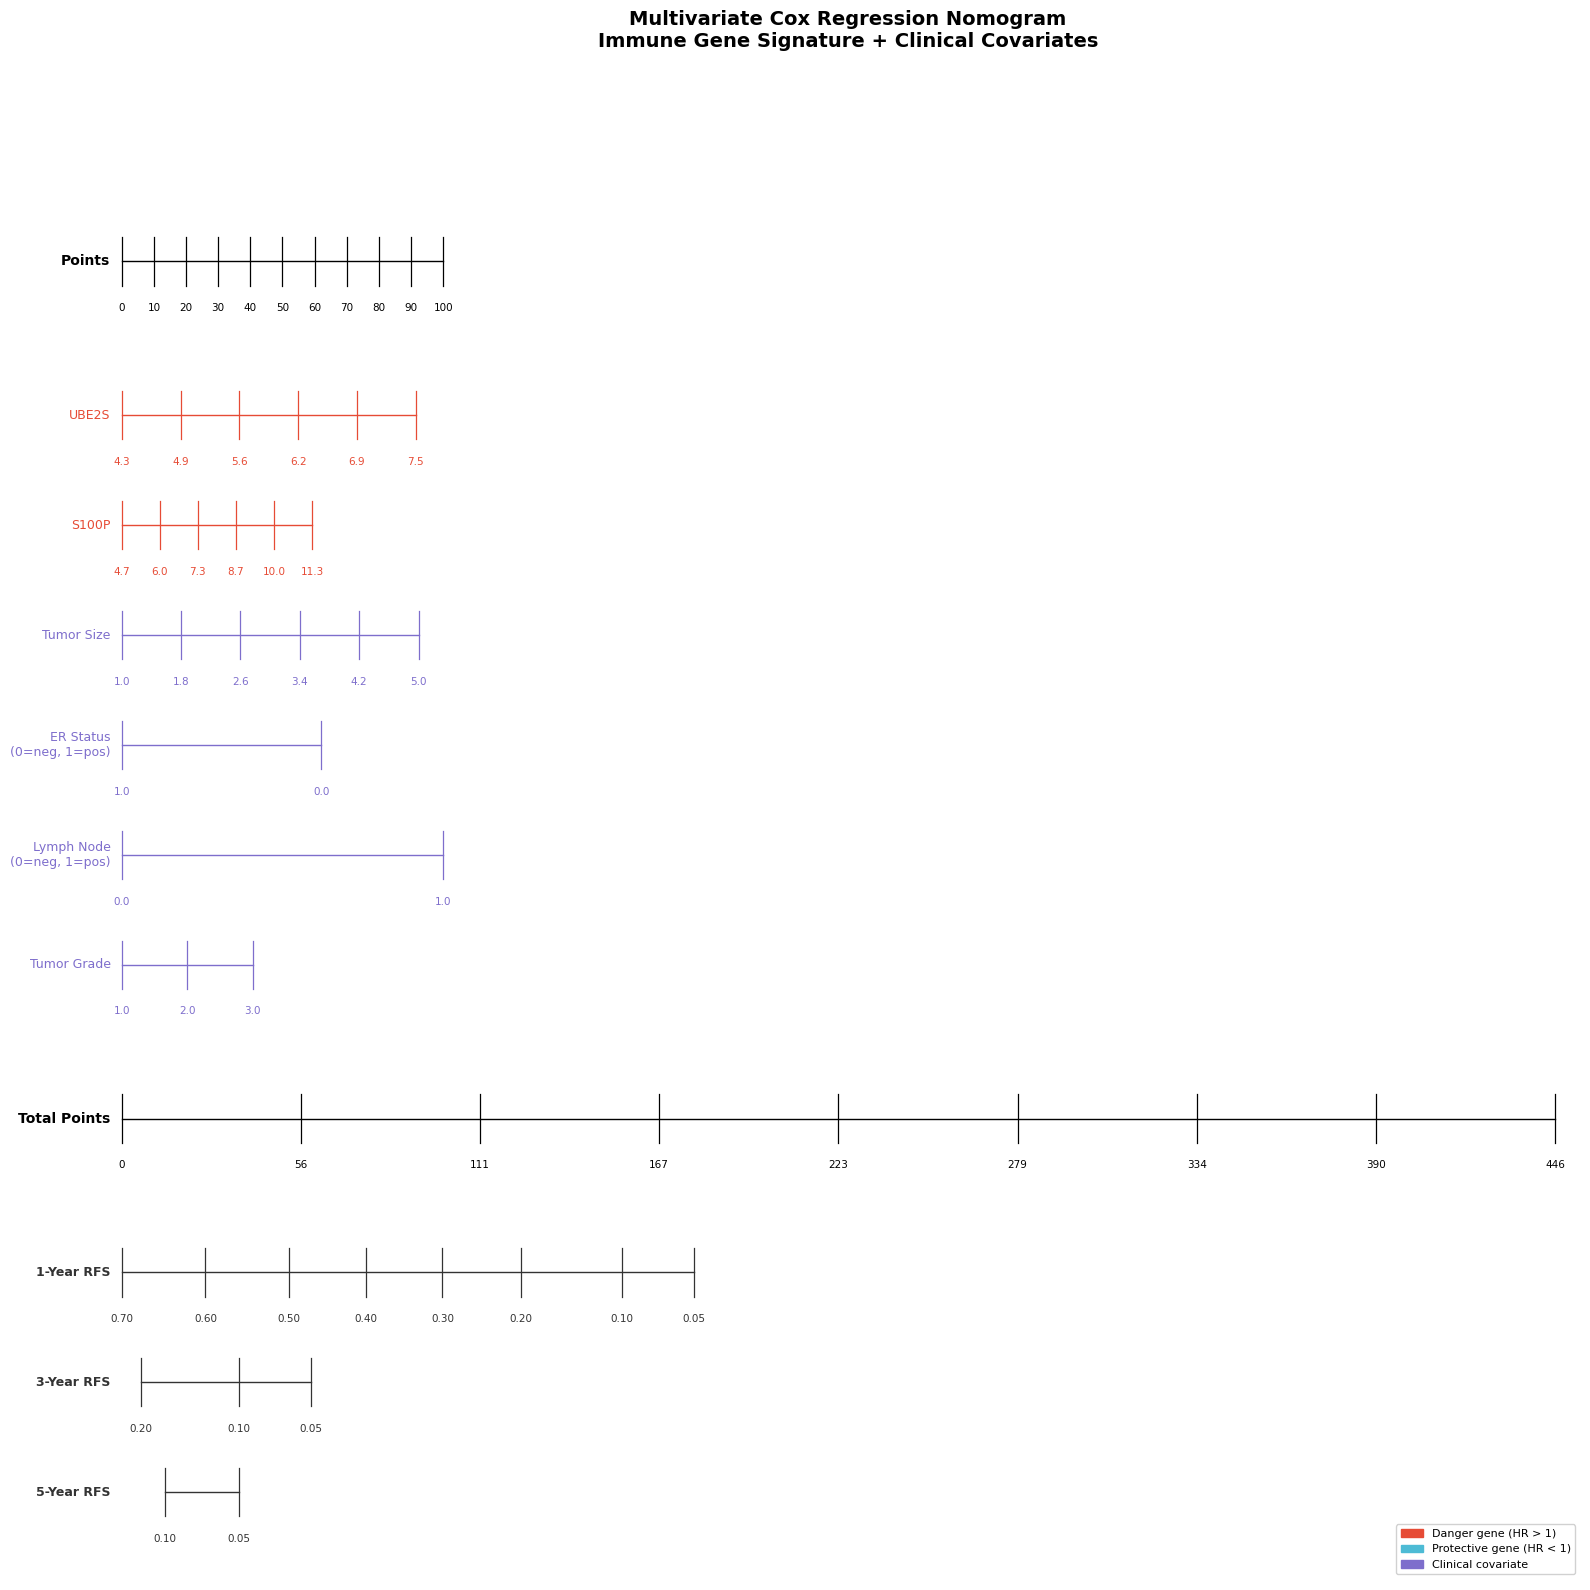

In [17]:
fig = draw_nomogram(
    cph,
    train_data,
    time_points=(365, 1095, 1825),
    time_labels=("1-Year RFS", "3-Year RFS", "5-Year RFS"),
    n_cont_ticks=6,
    title="Multivariate Cox Regression Nomogram\nImmune Gene Signature + Clinical Covariates",
    save_path='../visuals/nomogram.png'
)

## Model Validation

Two complementary checks:  
1. **C-index** — discrimination: how well the model ranks patients by risk  
2. **Calibration** — agreement between predicted and observed survival at a fixed time point

In [18]:
# ── Training-set means for clinical covariates (used to impute test sets) ─────
# The external test cohorts lack tumour/ER/grade metadata, so we fill those
# columns with training-set means before scoring. This is standard practice for
# external model validation when some covariates are unavailable.
clinical_train_means = train_data[CLINICAL_COVA].mean()
print('Clinical covariate means (training set):')
print(clinical_train_means.round(3).to_string())


def prepare_for_scoring(df, gene_cols, clinical_cols, impute_means):
    """
    Return a DataFrame ready for cph.predict_log_partial_hazard().
    - Selects available gene columns (genes present in df).
    - Adds clinical columns, imputing any that are absent with `impute_means`.
    - Drops rows with remaining NaN in gene or survival columns.
    """
    available_genes = [g for g in gene_cols if g in df.columns]
    sub = df[available_genes + ['relapse_free_time', 'relapse_free_event']].dropna().copy()

    for col in clinical_cols:
        if col in df.columns:
            sub[col] = df.loc[sub.index, col].fillna(float(impute_means[col]))
        else:
            sub[col] = float(impute_means[col])

    return sub, available_genes


def c_index_for(cph, df, gene_cols, clinical_cols, impute_means):
    """Harrell's C-index; imputes missing clinical columns with training means."""
    sub, avail_genes = prepare_for_scoring(df, gene_cols, clinical_cols, impute_means)
    if len(sub) == 0:
        return np.nan

    lp = cph.predict_log_partial_hazard(sub[avail_genes + clinical_cols])
    return concordance_index(
        sub['relapse_free_time'],
        -lp,
        sub['relapse_free_event']
    )


datasets = [
    ('Train',  train_data),
    ('Test 1', test_one),
    ('Test 2', test_two),
    ('Test 3', test_three),
]

print(f'\n{"Dataset":<10}  C-Index  Note')
print('-' * 52)
for name, df in datasets:
    ci   = c_index_for(cph, df, sig_genes, CLINICAL_COVA, clinical_train_means)
    note = '' if name == 'Train' else '(clinical vars imputed with train means)'
    print(f'{name:<10}  {ci:.4f}   {note}')

Clinical covariate means (training set):
tumor_size           2.545
er_status            0.663
lymph_node_status    0.564
tumor_grade          2.406

Dataset     C-Index  Note
----------------------------------------------------
Train       0.7686   
Test 1      0.6150   (clinical vars imputed with train means)
Test 2      0.5108   (clinical vars imputed with train means)
Test 3      0.6775   (clinical vars imputed with train means)


Saved: nomogram_calibration.png


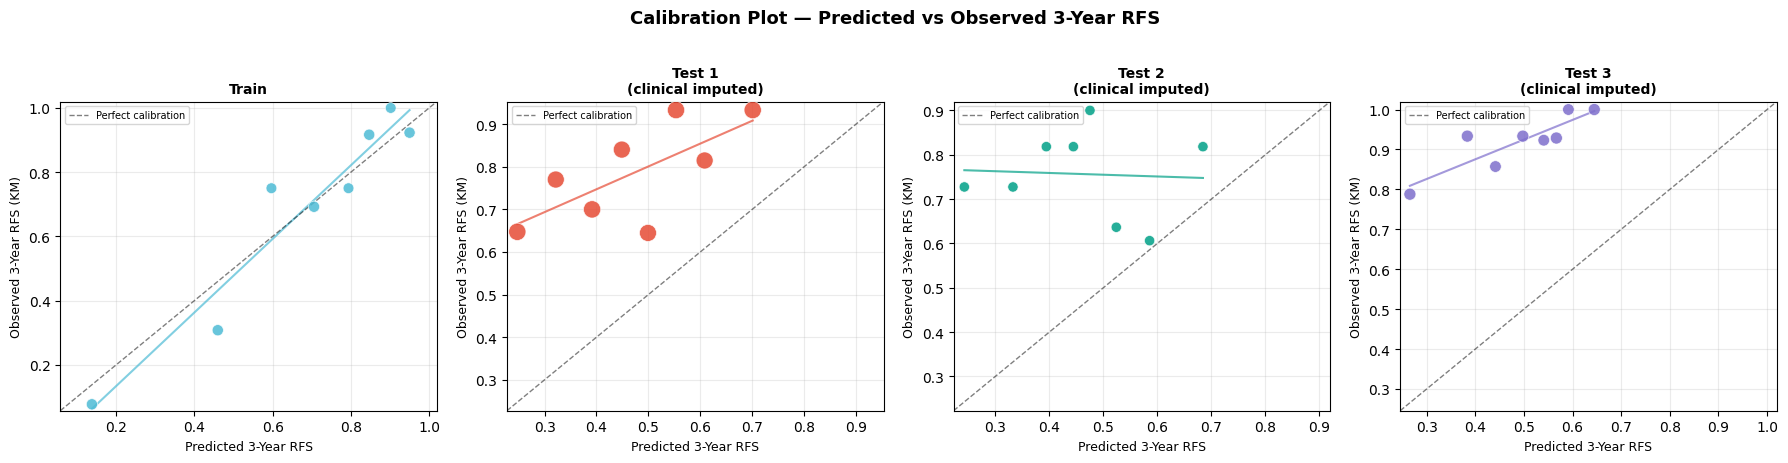

In [19]:
# ── Calibration plot ───────────────────────────────────────────────────────────
#
# Method:
#   1. Predict individual survival probability at time T for every patient.
#   2. Rank patients by predicted probability and divide into quantile groups.
#   3. For each group, estimate observed survival at T using Kaplan-Meier.
#   4. Plot observed vs predicted; a perfectly calibrated model lies on y = x.
#
# For test sets where clinical metadata is unavailable, columns are imputed
# with training-set means (same convention as C-index calculation above).

def calibration_plot(cph, df, time_point, ax, gene_cols, clinical_cols,
                     impute_means, n_groups=8, label='Train', color='#4DBBD5'):
    sub, avail_genes = prepare_for_scoring(df, gene_cols, clinical_cols, impute_means)

    if len(sub) < n_groups * 2:
        ax.text(0.5, 0.5, f'Not enough data\n(n={len(sub)})',
                ha='center', va='center', transform=ax.transAxes, fontsize=9)
        ax.set_title(label)
        return

    # Predicted survival at time_point for each patient
    pred_sf = cph.predict_survival_function(
        sub[avail_genes + clinical_cols], times=[time_point]
    ).T   # shape (n_patients, 1)
    sub = sub.copy()
    sub['pred_surv'] = pred_sf.values.flatten()

    # Assign quantile groups
    sub['group'] = pd.qcut(sub['pred_surv'], q=n_groups,
                            labels=False, duplicates='drop')

    kmf = KaplanMeierFitter()
    obs_list, pred_list, n_list = [], [], []

    for g in sorted(sub['group'].unique()):
        grp = sub[sub['group'] == g]
        kmf.fit(grp['relapse_free_time'], grp['relapse_free_event'])
        obs_list.append(float(kmf.predict(time_point)))
        pred_list.append(float(grp['pred_surv'].mean()))
        n_list.append(len(grp))

    obs_arr  = np.array(obs_list)
    pred_arr = np.array(pred_list)
    sizes    = np.array(n_list) * 5

    ax.scatter(pred_arr, obs_arr, s=sizes, color=color,
               alpha=0.85, edgecolors='white', linewidths=0.5, zorder=5)

    if len(pred_arr) > 1:
        m, b_coef = np.polyfit(pred_arr, obs_arr, 1)
        x_line = np.linspace(pred_arr.min(), pred_arr.max(), 50)
        ax.plot(x_line, m * x_line + b_coef, '-', color=color, lw=1.5, alpha=0.7)

    lo = min(pred_arr.min(), obs_arr.min()) - 0.02
    hi = max(pred_arr.max(), obs_arr.max()) + 0.02
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1, alpha=0.5, label='Perfect calibration')

    t_label = f'{time_point / 365:.0f}-Year'
    note    = '' if label == 'Train' else '\n(clinical imputed)'
    ax.set_xlabel(f'Predicted {t_label} RFS', fontsize=9)
    ax.set_ylabel(f'Observed {t_label} RFS (KM)', fontsize=9)
    ax.set_title(label + note, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.25)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)


# ── Plot calibration at 3 years (1095 days) ────────────────────────────────────
T_CAL  = 1095
COLORS = ['#4DBBD5', '#E64B35', '#00A087', '#7E6ECC']

fig_cal, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax_i, (name, df), col in zip(axes, datasets, COLORS):
    calibration_plot(cph, df, T_CAL, ax_i,
                     sig_genes, CLINICAL_COVA, clinical_train_means,
                     n_groups=8, label=name, color=col)

fig_cal.suptitle('Calibration Plot — Predicted vs Observed 3-Year RFS',
                 fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../visuals/nomogram_calibration.png', dpi=150, bbox_inches='tight')
print('Saved: nomogram_calibration.png')
plt.show()

## Example: Scoring an Individual Patient

Demonstrate how to use the nomogram (or the model directly) to obtain a predicted survival curve
for a single patient.

High Risk:
  1-year RFS = 0.609
  3-year RFS = 0.125
  5-year RFS = 0.076
Low Risk:
  1-year RFS = 0.991
  3-year RFS = 0.964
  5-year RFS = 0.955

Saved: nomogram_example_patients.png


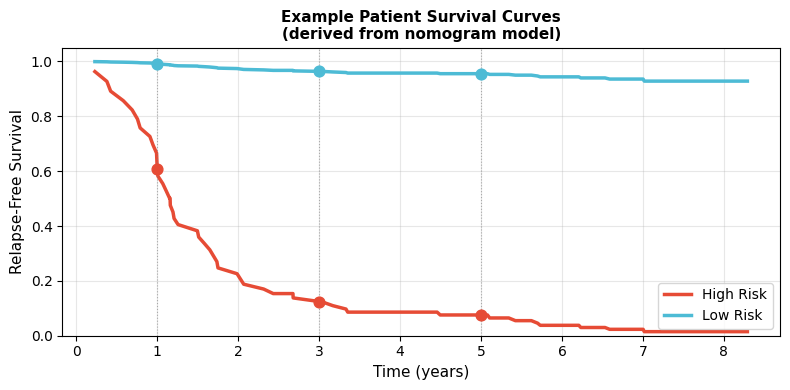

In [20]:
# ── Example patient ────────────────────────────────────────────────────────────
# Construct a representative high-risk and low-risk profile
gene_means = train_data[sig_genes].mean()

example_patients = pd.DataFrame([
    {
        **{g: gene_means[g] + 1.0 for g in sig_genes},   # high gene expression
        'tumor_size': 4, 'er_status': 0, 'lymph_node_status': 1, 'tumor_grade': 3,
        'label': 'High Risk'
    },
    {
        **{g: gene_means[g] - 1.0 for g in sig_genes},   # low gene expression
        'tumor_size': 1, 'er_status': 1, 'lymph_node_status': 0, 'tumor_grade': 1,
        'label': 'Low Risk'
    },
])

fig_ex, ax_ex = plt.subplots(figsize=(8, 4))
colors_ex = ['#E64B35', '#4DBBD5']

for (_, patient), col in zip(example_patients.iterrows(), colors_ex):
    label = patient['label']
    X_pat = patient[all_covariates].to_frame().T.astype(float)
    sf    = cph.predict_survival_function(X_pat)
    ax_ex.plot(sf.index / 365, sf.iloc[:, 0].values,
               label=label, color=col, lw=2.5)

    # Print predicted RFS at key time points
    print(f'{label}:')
    for t_yr, t_day in [(1, 365), (3, 1095), (5, 1825)]:
        prob = cph.predict_survival_function(X_pat, times=[t_day]).iloc[0, 0]
        print(f'  {t_yr}-year RFS = {prob:.3f}')

    # Annotate individual points on the curve
    for t_yr, t_day in [(1, 365), (3, 1095), (5, 1825)]:
        prob = float(cph.predict_survival_function(X_pat, times=[t_day]).iloc[0, 0])
        ax_ex.scatter(t_yr, prob, color=col, s=60, zorder=5)

ax_ex.set_xlabel('Time (years)', fontsize=11)
ax_ex.set_ylabel('Relapse-Free Survival', fontsize=11)
ax_ex.set_title('Example Patient Survival Curves\n(derived from nomogram model)',
                fontsize=11, fontweight='bold')
ax_ex.axvline(1, color='grey', ls=':', lw=0.8, alpha=0.6)
ax_ex.axvline(3, color='grey', ls=':', lw=0.8, alpha=0.6)
ax_ex.axvline(5, color='grey', ls=':', lw=0.8, alpha=0.6)
ax_ex.set_ylim(0, 1.05)
ax_ex.legend(fontsize=10)
ax_ex.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../visuals/nomogram_example_patients.png', dpi=150, bbox_inches='tight')
print('\nSaved: nomogram_example_patients.png')
plt.show()